# Subject prediction results: concise plots from compact forecast output

This notebook reads:

1. `version2_new_dataset_fitted.csv`, used to reconstruct historical and provisional shares;
2. `subject_prediction_forecasts.csv`, the compact forecast file exported by the model-selection notebook.

It then produces the same concise analysis:

- pure/applied basket ratio;
- largest subjects within each basket;
- fastest recent risers/decliners within pure/applied mathematics;
- reconstructed all-math subject shares;
- fastest recent risers/decliners among all mathematics.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 80)

## 1. Load data

In [2]:
DATA_PATH = Path("../../data/processed/version2_new_dataset_fitted.csv")
RESULTS_DIR = Path("outputs/subject_trend_predictions")
PREDICTION_PATH = RESULTS_DIR / "subject_prediction_forecasts.csv"

START_YEAR = 1960
END_YEAR = 2024
RECENT_START_YEAR = 2010
RECENT_END_YEAR = 2024
BASELINE_YEAR = 2024
PROVISIONAL_YEARS = [2025]

TOP_N = 5
MIN_RECENT_MEAN_SHARE = 0.25

In [3]:
nodes = pd.read_csv(DATA_PATH, low_memory=False)

nodes = nodes[
    nodes["subject_code"].notna()
    & nodes["year"].notna()
].copy()

#only keep the original data, and remove entries with predicted subject codes.
if "predicted_subject_code" in nodes.columns:
    nodes = nodes[nodes["predicted_subject_code"].isna()].copy()

nodes["subject_code"] = pd.to_numeric(
    nodes["subject_code"],
    errors="coerce",
)

nodes["year"] = pd.to_numeric(
    nodes["year"],
    errors="coerce",
)

nodes = nodes.dropna(
    subset=["subject_code", "year"]
)

nodes["year"] = nodes["year"].astype(int)

predictions = pd.read_csv(
    PREDICTION_PATH,
    dtype={"subject_code": str},
)

predictions["subject_code"] = (
    predictions["subject_code"].astype("string").str.zfill(2)
)
predictions["year"] = predictions["year"].astype(int)

print("Loaded original-label data:", f"{len(nodes):,}", "records")
print("Loaded forecast rows:", f"{len(predictions):,}")

Loaded original-label data: 167,749 records
Loaded forecast rows: 195


## 2. Reconstruct historical, provisional, and forecast results

In [4]:
def clean_subject_code(value):
    try:
        return str(int(float(value))).zfill(2)
    except (TypeError, ValueError):
        return str(value).zfill(2)


nodes["subject_code_clean"] = nodes["subject_code"].map(clean_subject_code)

nodes["basket"] = pd.NA
nodes.loc[nodes["subject_code"].lt(61), "basket"] = "Pure"
nodes.loc[nodes["subject_code"].gt(61), "basket"] = "Applied"
nodes = nodes.dropna(subset=["basket"]).copy()

subject_name_lookup = (
    nodes[["subject_code_clean", "subject_name"]]
    .dropna()
    .assign(subject_name=lambda x: x["subject_name"].astype(str).str.strip())
)
subject_name_lookup = subject_name_lookup[
    subject_name_lookup["subject_name"].ne("")
]

subject_name_lookup = (
    subject_name_lookup
    .groupby("subject_code_clean")["subject_name"]
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

def subject_label(code):
    code = clean_subject_code(code)
    name = subject_name_lookup.get(code)
    return f"{code} {name}" if name is not None else f"MSC {code}"


def build_subject_results(data, years, status):
    subset = data[data["year"].isin(years)].copy()

    total_counts = (
        subset
        .groupby("year")
        .size()
        .rename("total_classified_count")
    )

    frames = []

    for basket in ["Pure", "Applied"]:
        basket_data = subset[subset["basket"].eq(basket)].copy()

        subject_codes = sorted(
            basket_data["subject_code_clean"].unique()
        )

        counts = (
            pd.crosstab(
                basket_data["subject_code_clean"],
                basket_data["year"],
            )
            .reindex(index=subject_codes, columns=years, fill_value=0)
        )

        basket_counts = counts.sum(axis=0)

        shares = counts.div(
            basket_counts.replace(0, np.nan),
            axis=1,
        ) * 100

        frame = (
            shares
            .rename_axis("subject_code")
            .reset_index()
            .melt(
                id_vars="subject_code",
                var_name="year",
                value_name="share_percent",
            )
        )

        count_long = (
            counts
            .rename_axis("subject_code")
            .reset_index()
            .melt(
                id_vars="subject_code",
                var_name="year",
                value_name="subject_record_count",
            )
        )

        frame = frame.merge(
            count_long,
            on=["subject_code", "year"],
            how="left",
        )

        frame["basket"] = basket
        frame["status"] = status
        frame["basket_record_count"] = frame["year"].map(basket_counts)
        frame["total_classified_count"] = frame["year"].map(total_counts)

        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


completed_subjects = build_subject_results(
    nodes,
    years=list(range(START_YEAR, END_YEAR + 1)),
    status="observed_completed",
)

provisional_subjects = build_subject_results(
    nodes,
    years=PROVISIONAL_YEARS,
    status="observed_provisional",
)


subject_forecasts = predictions[
    predictions["record_type"].eq("subject_share_forecast")
].copy()

subject_forecasts = subject_forecasts.rename(
    columns={"value_percent": "share_percent"}
)

subject_forecasts["status"] = "forecast"
subject_forecasts["subject_record_count"] = np.nan
subject_forecasts["basket_record_count"] = np.nan
subject_forecasts["total_classified_count"] = np.nan

subject_results = pd.concat(
    [
        completed_subjects,
        provisional_subjects,
        subject_forecasts[
            [
                "basket",
                "subject_code",
                "year",
                "share_percent",
                "status",
                "subject_record_count",
                "basket_record_count",
                "total_classified_count",
            ]
        ],
    ],
    ignore_index=True,
)

subject_results["year"] = subject_results["year"].astype(int)
subject_results["subject_code"] = (
    subject_results["subject_code"].astype(str).str.zfill(2)
)

In [5]:
def build_ratio_results(data, years, status):
    subset = data[data["year"].isin(years)].copy()

    counts = (
        subset
        .groupby(["year", "basket"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=years,
            columns=["Pure", "Applied"],
            fill_value=0,
        )
    )

    ratios = counts.div(
        counts.sum(axis=1).replace(0, np.nan),
        axis=0,
    ) * 100

    ratio_long = (
        ratios
        .rename_axis("year")
        .reset_index()
        .melt(
            id_vars="year",
            var_name="basket",
            value_name="ratio_percent",
        )
    )

    ratio_long["status"] = status
    ratio_long["basket_record_count"] = [
        counts.loc[year, basket]
        for year, basket in zip(
            ratio_long["year"],
            ratio_long["basket"],
        )
    ]
    ratio_long["total_classified_count"] = (
        ratio_long["year"].map(counts.sum(axis=1))
    )

    return ratio_long


completed_ratios = build_ratio_results(
    nodes,
    years=list(range(START_YEAR, END_YEAR + 1)),
    status="observed_completed",
)

provisional_ratios = build_ratio_results(
    nodes,
    years=PROVISIONAL_YEARS,
    status="observed_provisional",
)

forecast_ratios = predictions[
    predictions["record_type"].eq("basket_ratio_forecast")
].copy()

forecast_ratios = forecast_ratios.rename(
    columns={"value_percent": "ratio_percent"}
)

forecast_ratios["status"] = "forecast"
forecast_ratios["basket_record_count"] = np.nan
forecast_ratios["total_classified_count"] = np.nan

ratio_results = pd.concat(
    [
        completed_ratios,
        provisional_ratios,
        forecast_ratios[
            [
                "basket",
                "year",
                "ratio_percent",
                "status",
                "basket_record_count",
                "total_classified_count",
            ]
        ],
    ],
    ignore_index=True,
)

## 3. Helper functions

In [ ]:
def select_largest_subjects(results, basket, top_n=5):
    ranking = (
        results[
            results["basket"].eq(basket)
            & results["status"].eq("observed_completed")
            & results["year"].between(
                RECENT_START_YEAR,
                RECENT_END_YEAR,
            )
        ]
        .groupby("subject_code")["share_percent"]
        .mean()
        .sort_values(ascending=False)
    )

    return pd.DataFrame(
        {
            "basket": basket,
            "subject_code": ranking.head(top_n).index,
        }
    )


def plot_subject_trajectories(
    results,
    selected_subjects,
    value_col,
    ylabel,
    title,
    historical_start_year=1990,
):
    fig, ax = plt.subplots(figsize=(13, 7))

    for _, selected in selected_subjects.iterrows():
        basket = selected["basket"]
        subject = selected["subject_code"]

        history = (
            results[
                results["basket"].eq(basket)
                & results["subject_code"].eq(subject)
                & results["status"].eq("observed_completed")
                & results["year"].ge(historical_start_year)
            ]
            .sort_values("year")
        )

        forecast = (
            results[
                results["basket"].eq(basket)
                & results["subject_code"].eq(subject)
                & results["status"].eq("forecast")
            ]
            .sort_values("year")
        )

        provisional = (
            results[
                results["basket"].eq(basket)
                & results["subject_code"].eq(subject)
                & results["status"].eq("observed_provisional")
                & results["year"].isin(PROVISIONAL_YEARS)
            ]
            .sort_values("year")
        )

        line, = ax.plot(
            history["year"],
            history[value_col],
            linewidth=2,
            label=f"{subject_label(subject)} ({basket})",
        )

        ax.plot(
            np.concatenate(
                [[history["year"].max()], forecast["year"]]
            ),
            np.concatenate(
                [[history[value_col].iloc[-1]], forecast[value_col]]
            ),
            linestyle="--",
            marker="o",
            color=line.get_color(),
        )

        if not provisional.empty:
            ax.scatter(
                provisional["year"],
                provisional[value_col],
                marker="X",
                s=100,
                color=line.get_color(),
                edgecolor="black",
                linewidth=0.6,
                zorder=4,
            )

    ax.axvline(
        BASELINE_YEAR,
        linestyle=":",
        linewidth=1.5,
        label="End of training data",
    )

    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()
    plt.show()

# weighted least square method to find the slope of share series in recent years: 2010-2024
def compute_recent_slopes(
    results,
    value_col,
    weight_col,
    group_cols=("basket", "subject_code"),
):
    records = []

    data = results[
        results["status"].eq("observed_completed")
        & results["year"].between(
            RECENT_START_YEAR,
            RECENT_END_YEAR,
        )
    ].dropna(subset=[value_col, weight_col]).copy()

    for keys, group in data.groupby(list(group_cols)):
        group = group.sort_values("year")

        x = group["year"].to_numpy(dtype=float)
        y = group[value_col].to_numpy(dtype=float)
        weights = group[weight_col].to_numpy(dtype=float)

        positive = weights > 0
        x = x[positive]
        y = y[positive]
        weights = weights[positive]

        if len(y) < 5:
            continue

        x_centered = x - x.mean()   

     
        slope, intercept = np.polyfit(
            x_centered,
            y,
            deg=1,
            w=np.sqrt(weights),
        )

        fitted = intercept + slope * x_centered
        weighted_mean = np.average(y, weights=weights)

        denominator = np.sum(
            weights * (y - weighted_mean) ** 2
        )

        weighted_r_squared = (
            1
            - np.sum(weights * (y - fitted) ** 2) / denominator
            if denominator > 0
            else np.nan
        )

        if not isinstance(keys, tuple):
            keys = (keys,)

        record = dict(zip(group_cols, keys))
        record.update(
            {
                "subject_label": subject_label(record["subject_code"]),
                "recent_mean_share": np.average(y, weights=weights),
                "slope_pp_per_year": slope,
                "slope_pp_per_decade": 10 * slope,
                "observed_change_pp": y[-1] - y[0],
                "weighted_r_squared": weighted_r_squared,
            }
        )
        records.append(record)

    return pd.DataFrame(records)


def rank_risers_decliners(trends, basket=None, top_n=5):
    data = trends[
        trends["recent_mean_share"].ge(MIN_RECENT_MEAN_SHARE)
    ].copy()

    if basket is not None:
        data = data[data["basket"].eq(basket)]

    risers = data.nlargest(top_n, "slope_pp_per_decade")
    decliners = data.nsmallest(top_n, "slope_pp_per_decade")

    return risers, decliners


def plot_slope_ranking(ranking, title):
    plot_data = ranking.sort_values("slope_pp_per_decade")

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        plot_data["subject_label"],
        plot_data["slope_pp_per_decade"],
    )

    ax.axvline(0, linewidth=1)
    ax.set_xlabel(
        "Observed trend, percentage points per decade"
    )
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)

    fig.tight_layout()
    plt.show()


def compact_trend_table(frame):
    return frame[
        [
            "subject_label",
            "basket",
            "recent_mean_share",
            "slope_pp_per_decade",
            "observed_change_pp",
            "weighted_r_squared",
        ]
    ].round(3)

## 4. Pure/applied basket ratio

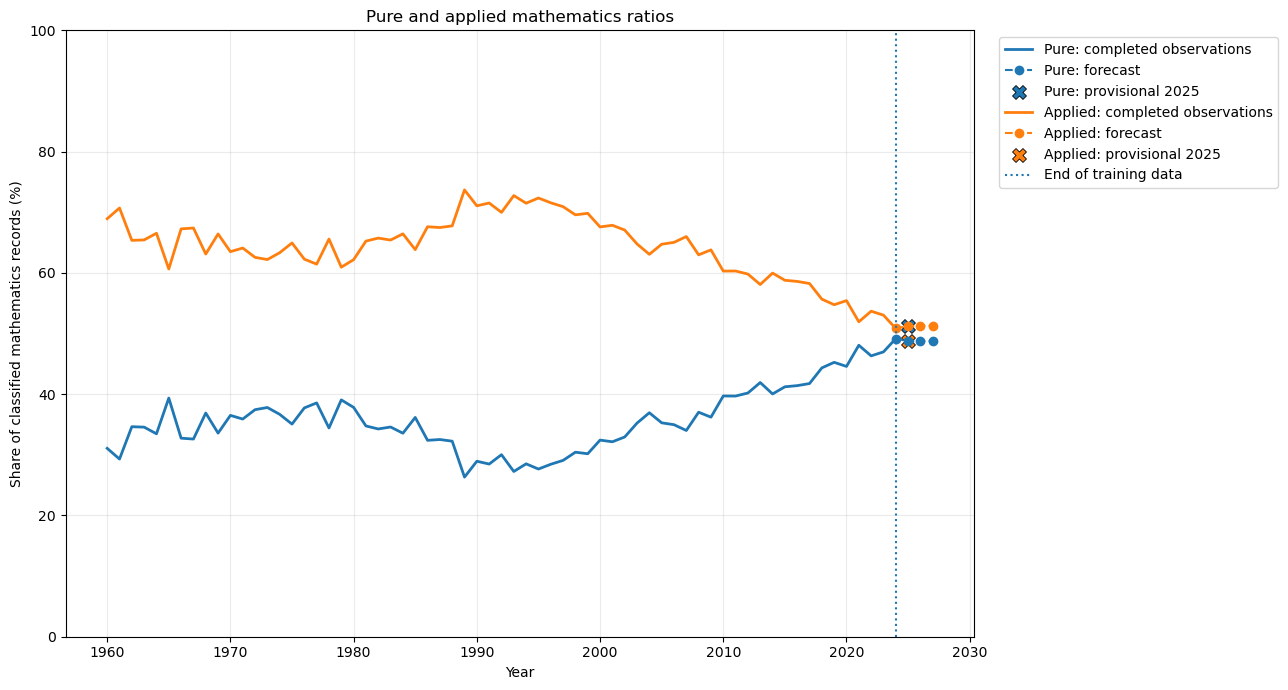

In [7]:
def plot_basket_ratio_results(
    completed,
    provisional,
    forecast,
    historical_start_year=1960,
):
    historical = completed[
        completed["year"].ge(historical_start_year)
    ].copy()

    fig, ax = plt.subplots(figsize=(13, 7))

    for basket in ["Pure", "Applied"]:
        history = (
            historical[historical["basket"].eq(basket)]
            .sort_values("year")
        )
        future = (
            forecast[forecast["basket"].eq(basket)]
            .sort_values("year")
        )
        provisional_values = (
            provisional[provisional["basket"].eq(basket)]
            .sort_values("year")
        )

        line, = ax.plot(
            history["year"],
            history["ratio_percent"],
            linewidth=2,
            label=f"{basket}: completed observations",
        )

        ax.plot(
            np.concatenate(
                [[history["year"].max()], future["year"]]
            ),
            np.concatenate(
                [[history["ratio_percent"].iloc[-1]],
                 future["ratio_percent"]]
            ),
            linestyle="--",
            marker="o",
            color=line.get_color(),
            label=f"{basket}: forecast",
        )

        ax.scatter(
            provisional_values["year"],
            provisional_values["ratio_percent"],
            marker="X",
            s=100,
            color=line.get_color(),
            edgecolor="black",
            linewidth=0.6,
            label=f"{basket}: provisional 2025",
        )

    ax.axvline(
        BASELINE_YEAR,
        linestyle=":",
        linewidth=1.5,
        label="End of training data",
    )

    ax.set_xlabel("Year")
    ax.set_ylabel(
        "Share of classified mathematics records (%)"
    )
    ax.set_title("Pure and applied mathematics ratios")
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.25)
    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )

    fig.tight_layout()
    plt.show()


plot_basket_ratio_results(
    completed=completed_ratios,
    provisional=provisional_ratios,
    forecast=forecast_ratios,
)

## 5. Largest subjects within pure and applied mathematics

,basket,subject_code,subject_label
0,Pure,35,35 Partial differential equations
1,Pure,60,60 Probability theory and stochastic processes
2,Pure,11,11 Number theory
3,Pure,05,05 Combinatorics
4,Pure,14,14 Algebraic geometry
0,Applied,68,68 Computer science
1,Applied,62,62 Statistics
2,Applied,91,"91 Game theory, economics, social and behavior..."
3,Applied,65,65 Numerical analysis
4,Applied,90,"90 Operations research, mathematical programming"


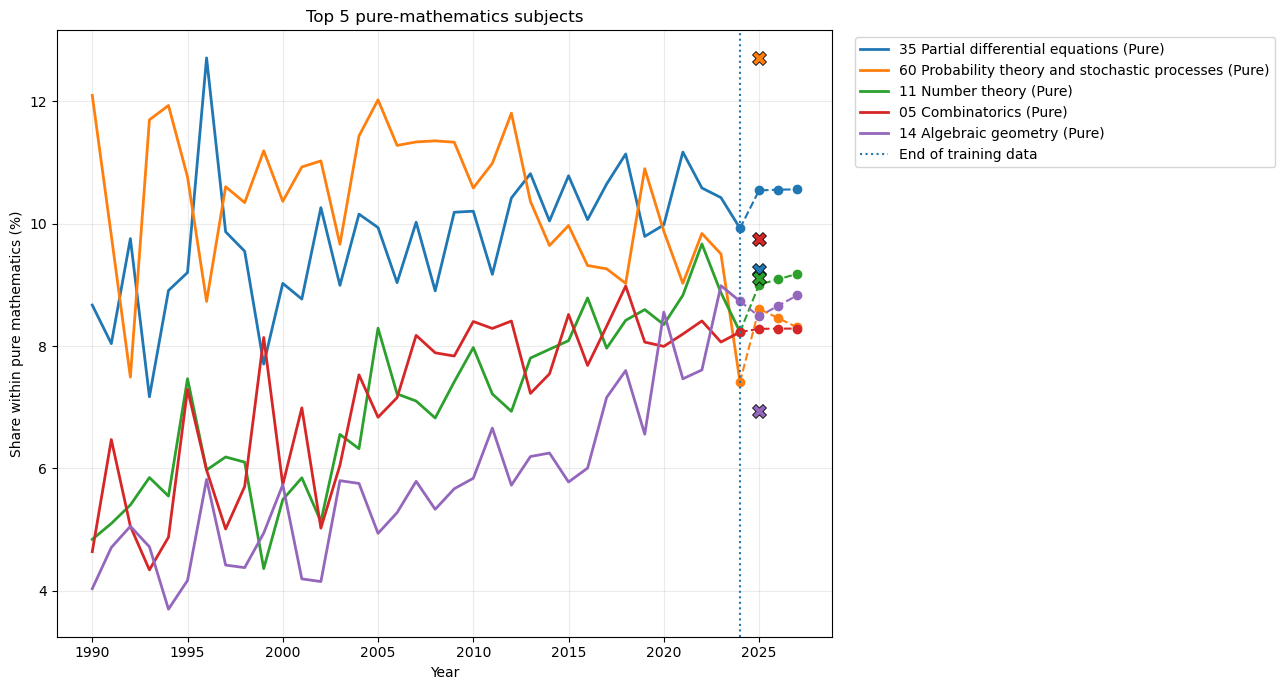

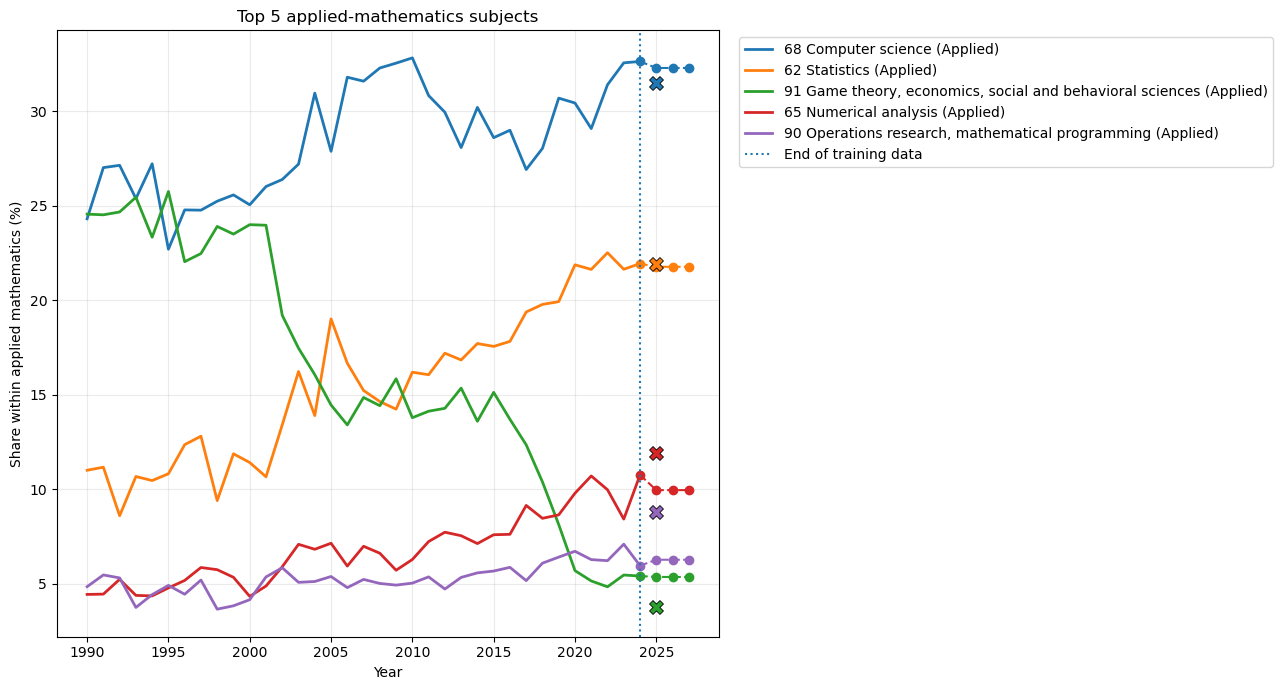

In [8]:
top_pure_subjects = select_largest_subjects(
    subject_results,
    basket="Pure",
    top_n=TOP_N,
)

top_applied_subjects = select_largest_subjects(
    subject_results,
    basket="Applied",
    top_n=TOP_N,
)

display(
    pd.concat([top_pure_subjects, top_applied_subjects])
    .assign(subject_label=lambda x: x["subject_code"].map(subject_label))
)

plot_subject_trajectories(
    results=subject_results,
    selected_subjects=top_pure_subjects,
    value_col="share_percent",
    ylabel="Share within pure mathematics (%)",
    title=f"Top {TOP_N} pure-mathematics subjects",
    historical_start_year=1990,
)

plot_subject_trajectories(
    results=subject_results,
    selected_subjects=top_applied_subjects,
    value_col="share_percent",
    ylabel="Share within applied mathematics (%)",
    title=f"Top {TOP_N} applied-mathematics subjects",
    historical_start_year=1990,
)

## 6. Fastest recent risers and decliners within each basket


Pure: fastest recent observed risers


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
28,14 Algebraic geometry,Pure,6.912,2.064,2.893,0.691
25,11 Number theory,Pure,8.211,1.157,0.255,0.561
57,53 Differential geometry,Pure,5.285,1.048,1.754,0.632
59,55 Algebraic topology,Pure,2.635,0.907,1.774,0.515
32,"18 Category theory, homological algebra",Pure,1.482,0.834,0.130,0.531


Pure: fastest recent observed decliners


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
62,60 Probability theory and stochastic processes,Pure,9.888,-1.539,-3.172,0.437
30,16 Associative rings and algebras,Pure,2.411,-0.556,-0.758,0.602
19,00 General,Pure,1.368,-0.529,-1.207,0.471
42,34 Ordinary differential equations,Pure,1.823,-0.500,-0.771,0.421
52,46 Functional analysis,Pure,3.699,-0.443,0.543,0.167


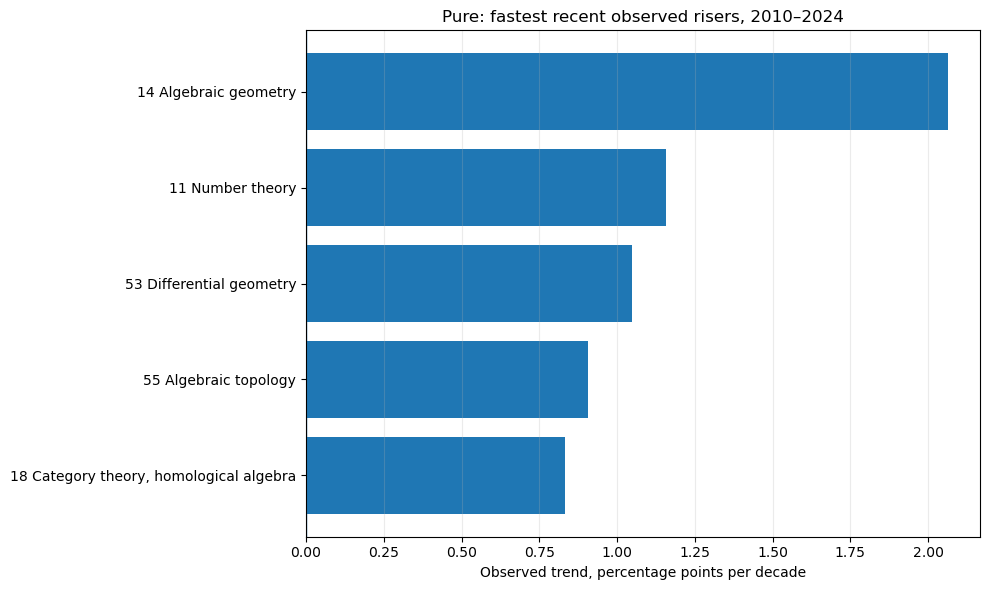

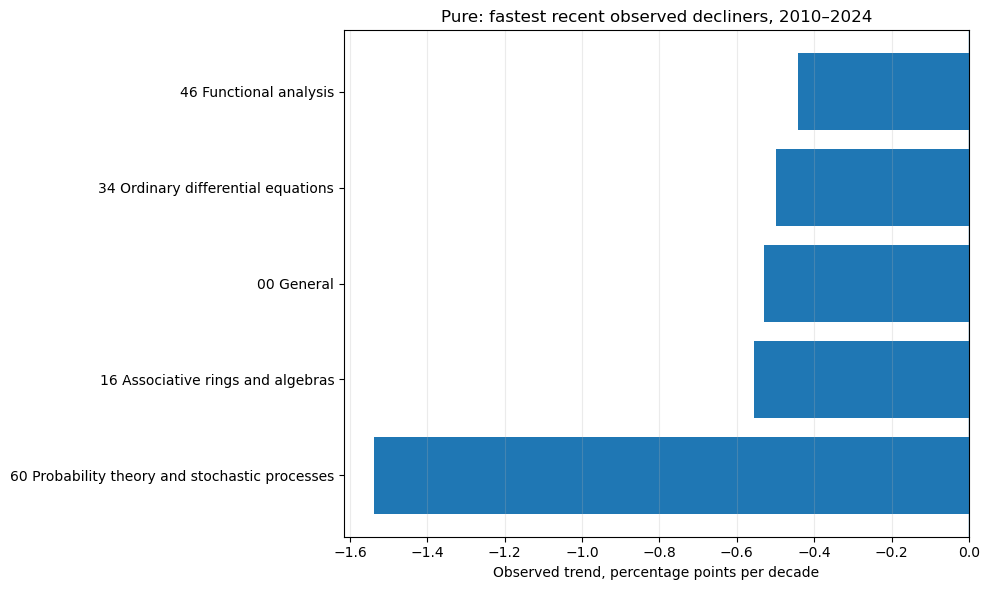


Applied: fastest recent observed risers


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
0,62 Statistics,Applied,18.785,4.986,5.744,0.931
1,65 Numerical analysis,Applied,8.245,2.614,4.472,0.753
13,"90 Operations research, mathematical programming",Applied,5.738,1.239,0.923,0.677
8,81 Quantum Theory,Applied,2.276,0.353,-0.523,0.171
4,74 Mechanics of deformable solids,Applied,1.616,0.313,-0.136,0.291


Applied: fastest recent observed decliners


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
14,"91 Game theory, economics, social and behavior...",Applied,11.279,-8.376,-8.374,0.799
17,"94 Information and communication, circuits",Applied,4.738,-1.284,-1.824,0.755
12,86 Geophysics,Applied,0.653,-0.254,-0.384,0.401
6,"78 Optics, electromagnetic theory",Applied,0.402,-0.219,-0.444,0.403
10,83 Relativity and gravitational theory,Applied,1.174,-0.210,-0.526,0.214


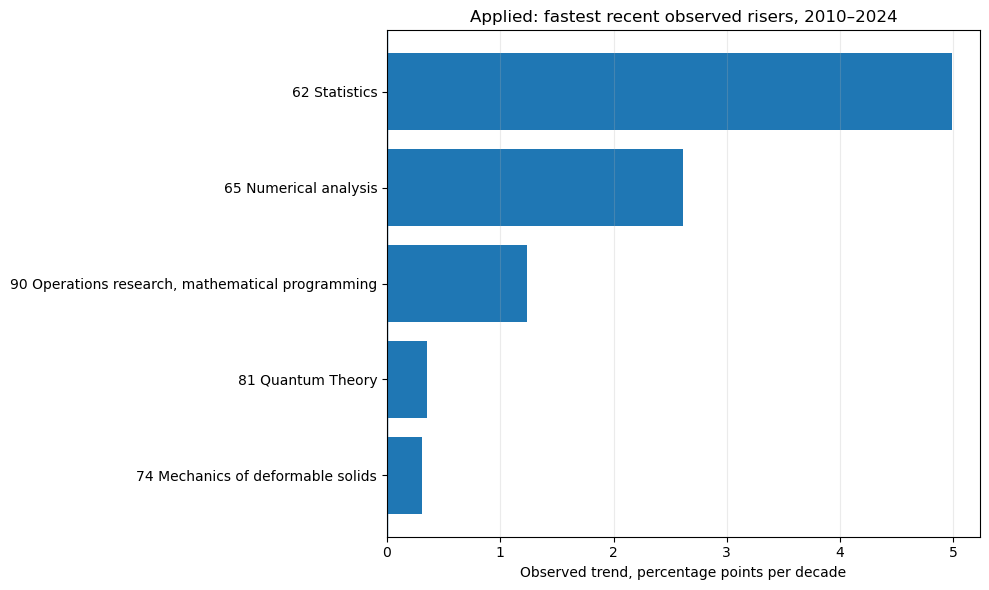

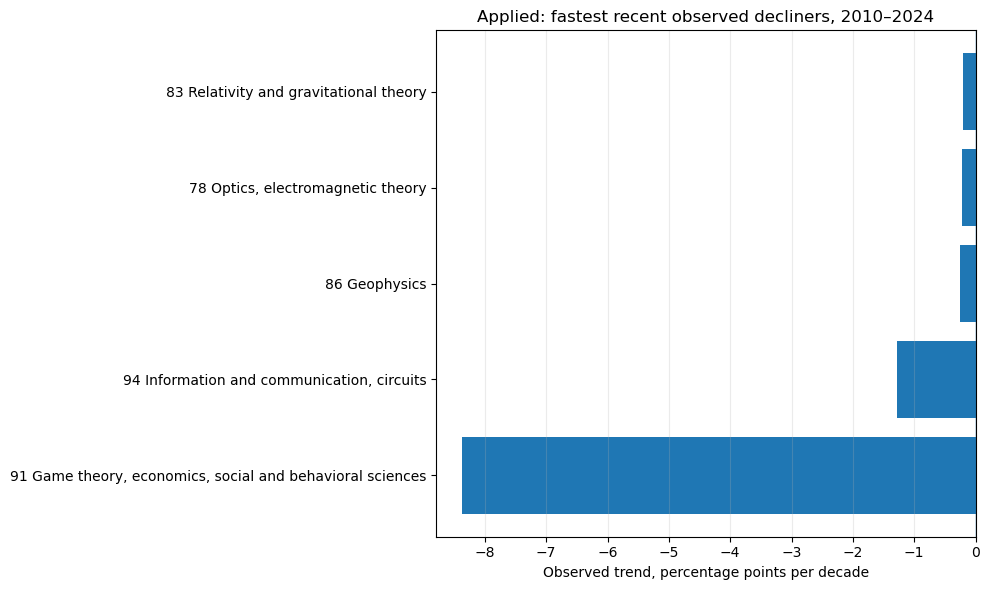

In [9]:
within_basket_trends = compute_recent_slopes(
    results=subject_results,
    value_col="share_percent",
    weight_col="basket_record_count",
)

for basket in ["Pure", "Applied"]:
    risers, decliners = rank_risers_decliners(
        within_basket_trends,
        basket=basket,
        top_n=TOP_N,
    )

    print(f"\n{basket}: fastest recent observed risers")
    display(compact_trend_table(risers))

    print(f"{basket}: fastest recent observed decliners")
    display(compact_trend_table(decliners))

    plot_slope_ranking(
        risers,
        title=(
            f"{basket}: fastest recent observed risers, "
            f"{RECENT_START_YEAR}–{RECENT_END_YEAR}"
        ),
    )

    plot_slope_ranking(
        decliners,
        title=(
            f"{basket}: fastest recent observed decliners, "
            f"{RECENT_START_YEAR}–{RECENT_END_YEAR}"
        ),
    )

## 7. Reconstruct all-math subject shares

The within-basket subject share is converted to an all-math share by multiplying by the corresponding basket ratio:

$$
P(s\mid \mathrm{all\ math})
=
P(s\mid \mathrm{basket})
P(\mathrm{basket}\mid \mathrm{all\ math}).
$$


In [10]:
ratio_for_merge = ratio_results[
    ["basket", "year", "status", "ratio_percent"]
].copy()

overall_subject_results = subject_results.merge(
    ratio_for_merge,
    on=["basket", "year", "status"],
    how="left",
)

overall_subject_results["overall_share_percent"] = (
    overall_subject_results["share_percent"]
    * overall_subject_results["ratio_percent"]
    / 100
)

## 8. Fastest recent risers and decliners among all mathematics

All mathematics: fastest recent observed risers


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
0,62 Statistics,Applied,10.722,1.543,1.388,0.747
28,14 Algebraic geometry,Pure,2.967,1.361,1.975,0.809
25,11 Number theory,Pure,3.525,1.052,0.880,0.832
1,65 Numerical analysis,Applied,4.706,0.915,1.679,0.567
57,53 Differential geometry,Pure,2.269,0.809,1.321,0.769


All mathematics: fastest recent observed decliners


,subject_label,basket,recent_mean_share,slope_pp_per_decade,observed_change_pp,weighted_r_squared
14,"91 Game theory, economics, social and behavior...",Applied,6.438,-5.439,-5.561,0.835
2,68 Computer science,Applied,17.059,-1.812,-3.201,0.392
17,"94 Information and communication, circuits",Applied,2.704,-1.034,-1.445,0.883
10,83 Relativity and gravitational theory,Applied,0.670,-0.196,-0.404,0.447
12,86 Geophysics,Applied,0.373,-0.186,-0.260,0.522


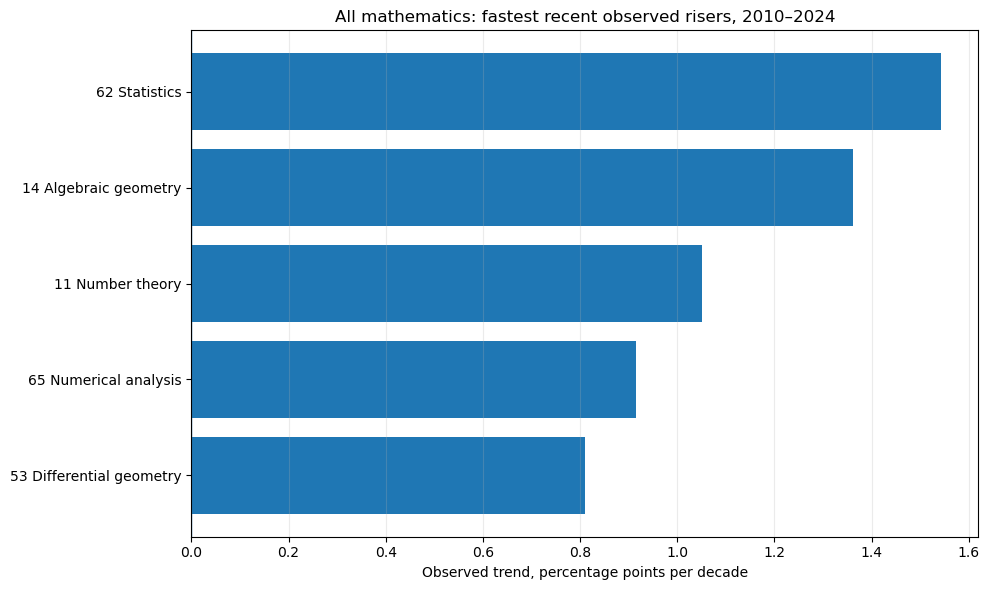

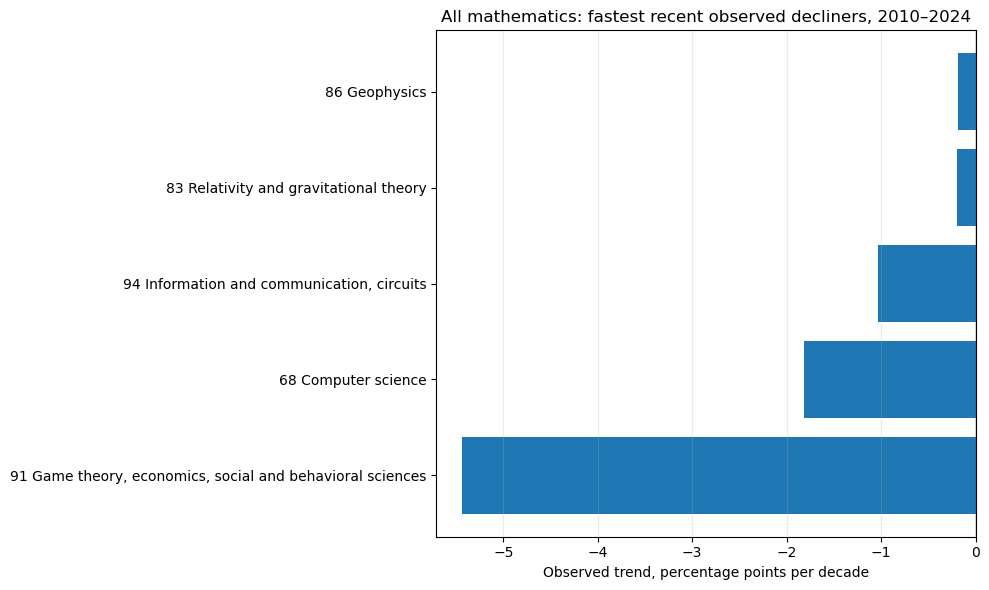

In [11]:
all_math_trends = compute_recent_slopes(
    results=overall_subject_results,
    value_col="overall_share_percent",
    weight_col="total_classified_count",
)

all_math_risers, all_math_decliners = rank_risers_decliners(
    all_math_trends,
    basket=None,
    top_n=TOP_N,
)

print("All mathematics: fastest recent observed risers")
display(compact_trend_table(all_math_risers))

print("All mathematics: fastest recent observed decliners")
display(compact_trend_table(all_math_decliners))

plot_slope_ranking(
    all_math_risers,
    title=(
        "All mathematics: fastest recent observed risers, "
        f"{RECENT_START_YEAR}–{RECENT_END_YEAR}"
    ),
)

plot_slope_ranking(
    all_math_decliners,
    title=(
        "All mathematics: fastest recent observed decliners, "
        f"{RECENT_START_YEAR}–{RECENT_END_YEAR}"
    ),
)

## 9. Trajectories for all-math risers and decliners

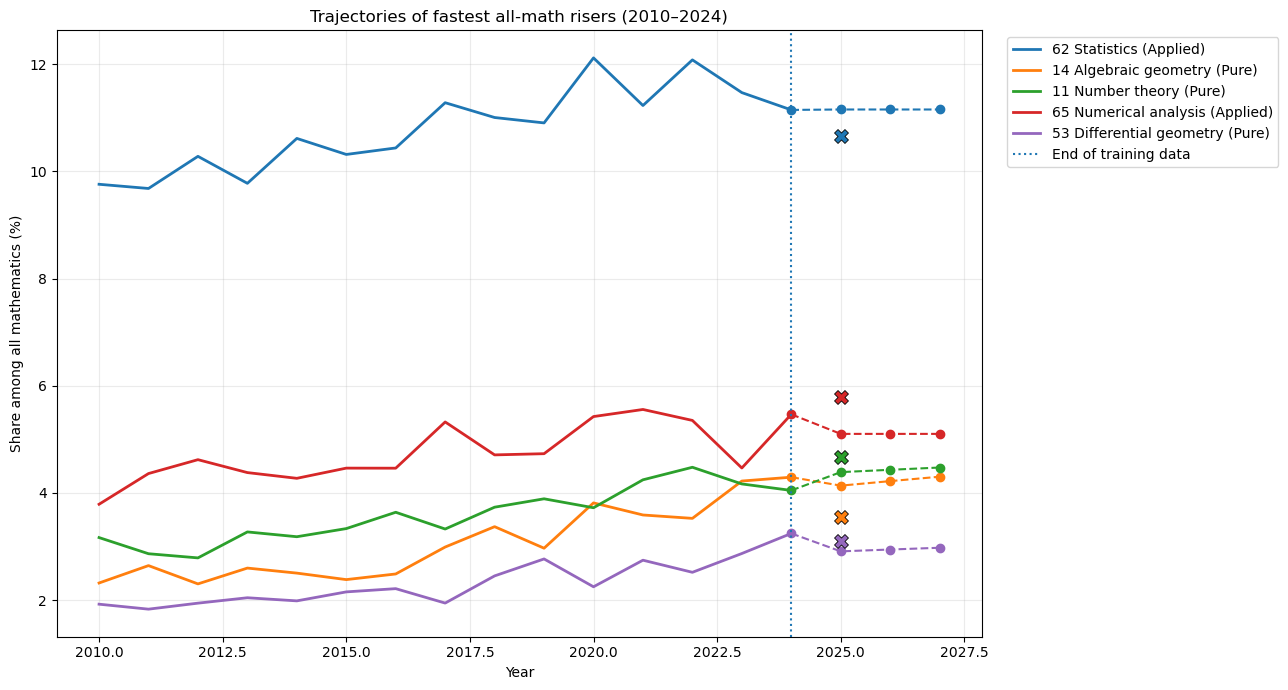

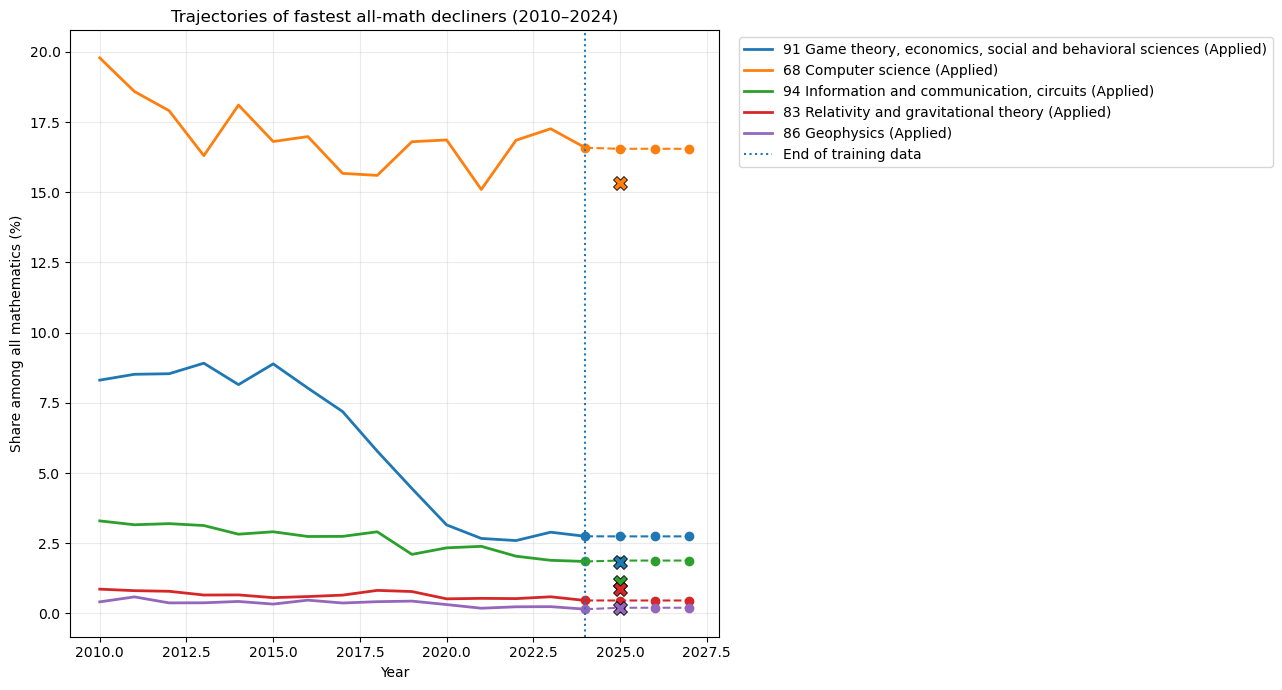

In [12]:
plot_subject_trajectories(
    results=overall_subject_results,
    selected_subjects=all_math_risers[["basket", "subject_code"]],
    value_col="overall_share_percent",
    ylabel="Share among all mathematics (%)",
    title=(
        "Trajectories of fastest all-math risers "
        f"({RECENT_START_YEAR}–{RECENT_END_YEAR})"
    ),
    historical_start_year=RECENT_START_YEAR,
)

plot_subject_trajectories(
    results=overall_subject_results,
    selected_subjects=all_math_decliners[["basket", "subject_code"]],
    value_col="overall_share_percent",
    ylabel="Share among all mathematics (%)",
    title=(
        "Trajectories of fastest all-math decliners "
        f"({RECENT_START_YEAR}–{RECENT_END_YEAR})"
    ),
    historical_start_year=RECENT_START_YEAR,
)

## 10. Interpretation summary

- The model-selection notebook exports only forecast values.
- Historical and provisional observations are reconstructed here from the fitted dataset.
- Within-basket rankings answer which subjects are rising or declining inside pure/applied mathematics.
- All-math rankings additionally incorporate the changing pure/applied basket ratio.
- Forecast curves are visual comparisons, not the basis for riser/decliner rankings.
- The 2025 points are provisional; 2026 is excluded because the current sample is too small.